In this notebook we will look at a kidney disease dataset with a wide range of markers. We will demonstrate the use of dimensionality reduction, and then subsequently feeding the reduced dimension dataset into a basic classification model. PCA will be used for dimensionality reduction and we will use logistic regression for out classification. 

This notebook mainly focuses on the application of the PCA process for dimensionality reduction. The addition of classification analysis is more to show how post PCA data can be fed into further processes.

In [1]:
# Packages installation
%pip install pandas numpy matplotlib seaborn scikit-learn
print("✅ Packages installed successfully.")

Note: you may need to restart the kernel to use updated packages.
✅ Packages installed successfully.


In [2]:
import pandas as pd
import numpy as np

# 3.7.1 for Kaggle compatibility
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("✅ Dependencies loaded successfully.")

✅ Dependencies loaded successfully.


In [3]:
df = pd.read_csv("data/kidney_disease.csv")
print("✅ Dataset read successfully.")

✅ Dataset read successfully.


## Exploratory Data Analysis

In [4]:
df.head().T

,0,1,2,3,4
id,0,1,2,3,4
age,48.0,7.0,62.0,48.0,51.0
bp,80.0,50.0,80.0,70.0,80.0
sg,1.02,1.02,1.01,1.005,1.01
al,1.0,4.0,2.0,4.0,2.0
su,0.0,0.0,3.0,0.0,0.0
rbc,NaN,NaN,normal,normal,normal
pc,normal,normal,normal,abnormal,normal
pcc,notpresent,notpresent,notpresent,present,notpresent
ba,notpresent,notpresent,notpresent,notpresent,notpresent


We will rename the dataframe columns with reference to the above key in order to improve readability.

In [5]:
df.drop('id', axis = 1, inplace = True)
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'anemia', 'class']


Looking at the dataframe info, we can see a wide range of variables with different types. Furthermore there are many null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
blood_pressure,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
specific_gravity,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
albumin,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
sugar,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
blood_glucose_random,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
blood_urea,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
serum_creatinine,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sodium,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
potassium,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


In [8]:
df.isnull().sum()


age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
haemoglobin                 52
packed_cell_volume          70
white_blood_cell_count     105
red_blood_cell_count       130
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
anemia                       1
class                        0
dtype: int64

In [9]:
# View missing counts
df.isnull().sum().sort_values(ascending=False).head(10)

red_blood_cells           152
red_blood_cell_count      130
white_blood_cell_count    105
potassium                  88
sodium                     87
packed_cell_volume         70
pus_cell                   65
haemoglobin                52
sugar                      49
specific_gravity           47
dtype: int64

In [ ]:
# Missing data heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Data Pattern (Yellow = Missing, Purple = Present)')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

# Missing data percentage by feature
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    plt.figure(figsize=(10, 6))
    missing_pct.plot(kind='barh', color='coral')
    plt.xlabel('Missing Data (%)')
    plt.ylabel('Features')
    plt.title('Percentage of Missing Data by Feature')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### Missing Data Visualization

Visualizing missing data patterns helps understand data quality and potential biases.

We will start with an analysis of the categorical variables to see how they are distributed.

C:\Users\RickReyJim\AppData\Local\Temp\ipykernel_8564\3991186973.py:25: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
c:\GIT\CDK\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\GIT\CDK\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


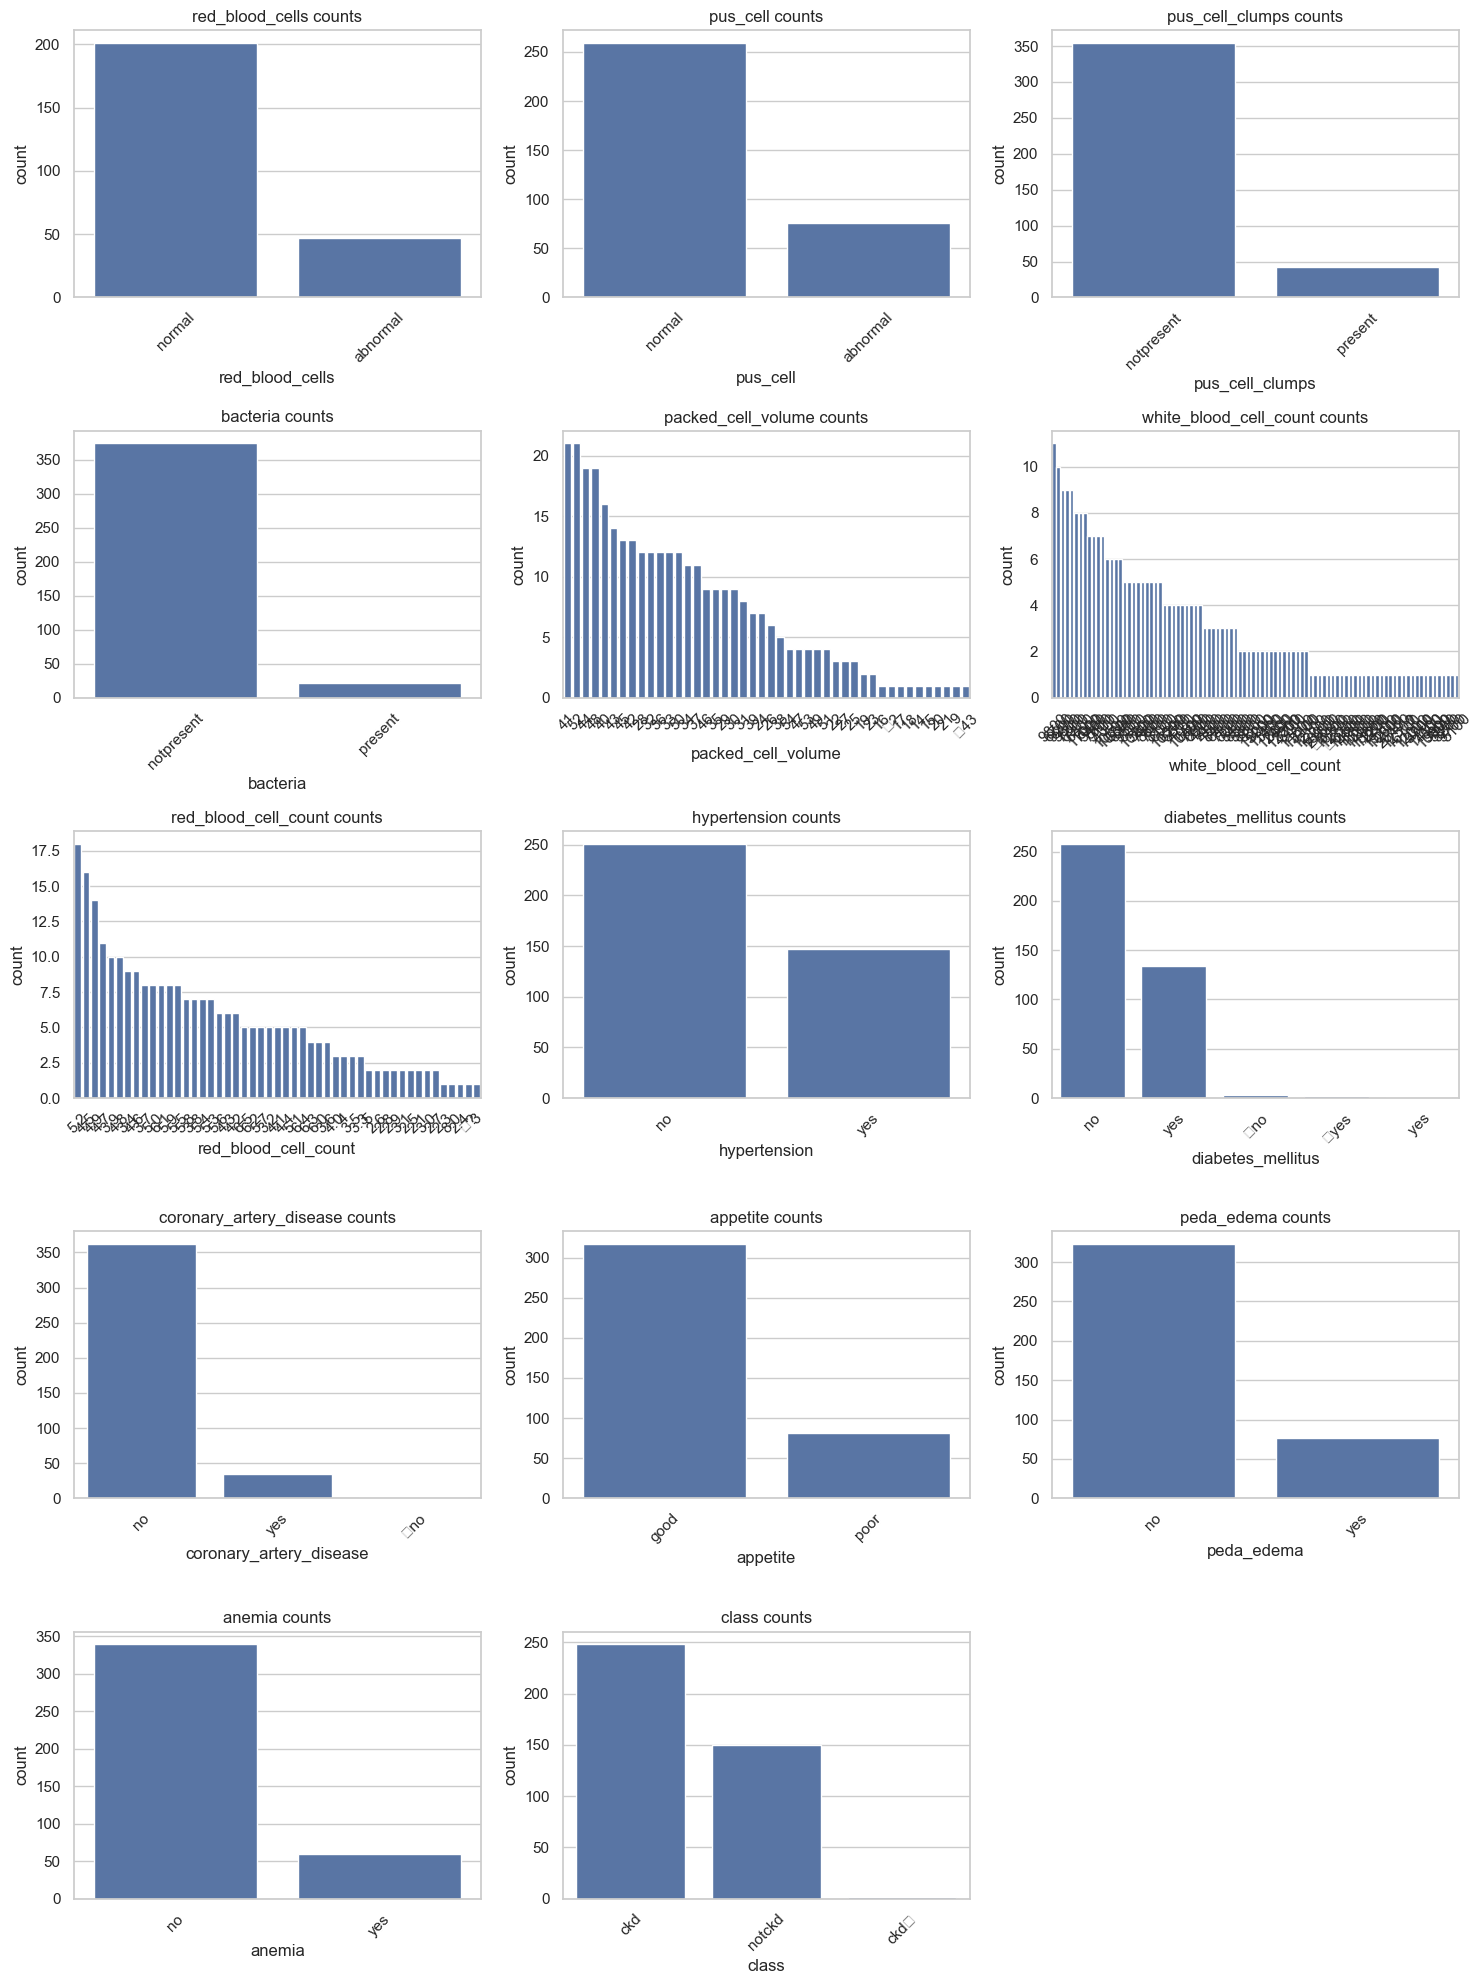

In [10]:
# Automatically detect categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [col for col in cat_cols]

# Set plotting style
sns.set(style="whitegrid")

# Determine grid size
n_cols = 3  # number of columns in the grid
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  # automatically calculate rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()  # flatten in case of multiple rows

# Plot each categorical column
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'{col} counts')
    axes[i].tick_params(axis='x', rotation=45)

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From this we can see, unclean data regarding:
- variation in vaiable names - "no", "yes", " no" etc
- numeric variables seemly displayed as a object

As fixing this does not cause data leakage we can do it before the train test split.

We can also take note of the balance in the "class" categorical variable. This is our target variable and shows whether a person has kidney disease or not, as it is not 50/50 we will need to take this balance into account.

In [11]:
# fixing misspelled values

mapping = {
    "yes": "yes", 
    " yes": "yes", 
    "\tyes": "yes",
    "no": "no", 
    "\tno": "no"
}

df["diabetes_mellitus"] = df["diabetes_mellitus"].map(mapping).fillna(np.nan)
df["coronary_artery_disease"] = df["coronary_artery_disease"].map(mapping).fillna(np.nan)

mapping = {
    "ckd": "ckd", 
    "ckd\t": "ckd",
    "notckd": "notckd"
}

df["class"] = df["class"].map(mapping).fillna(np.nan)

In [12]:
# Convert object columns that are actually numeric
num_like_cols = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']

for col in num_like_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Inspecting the numeric variables to see how they are distributed.

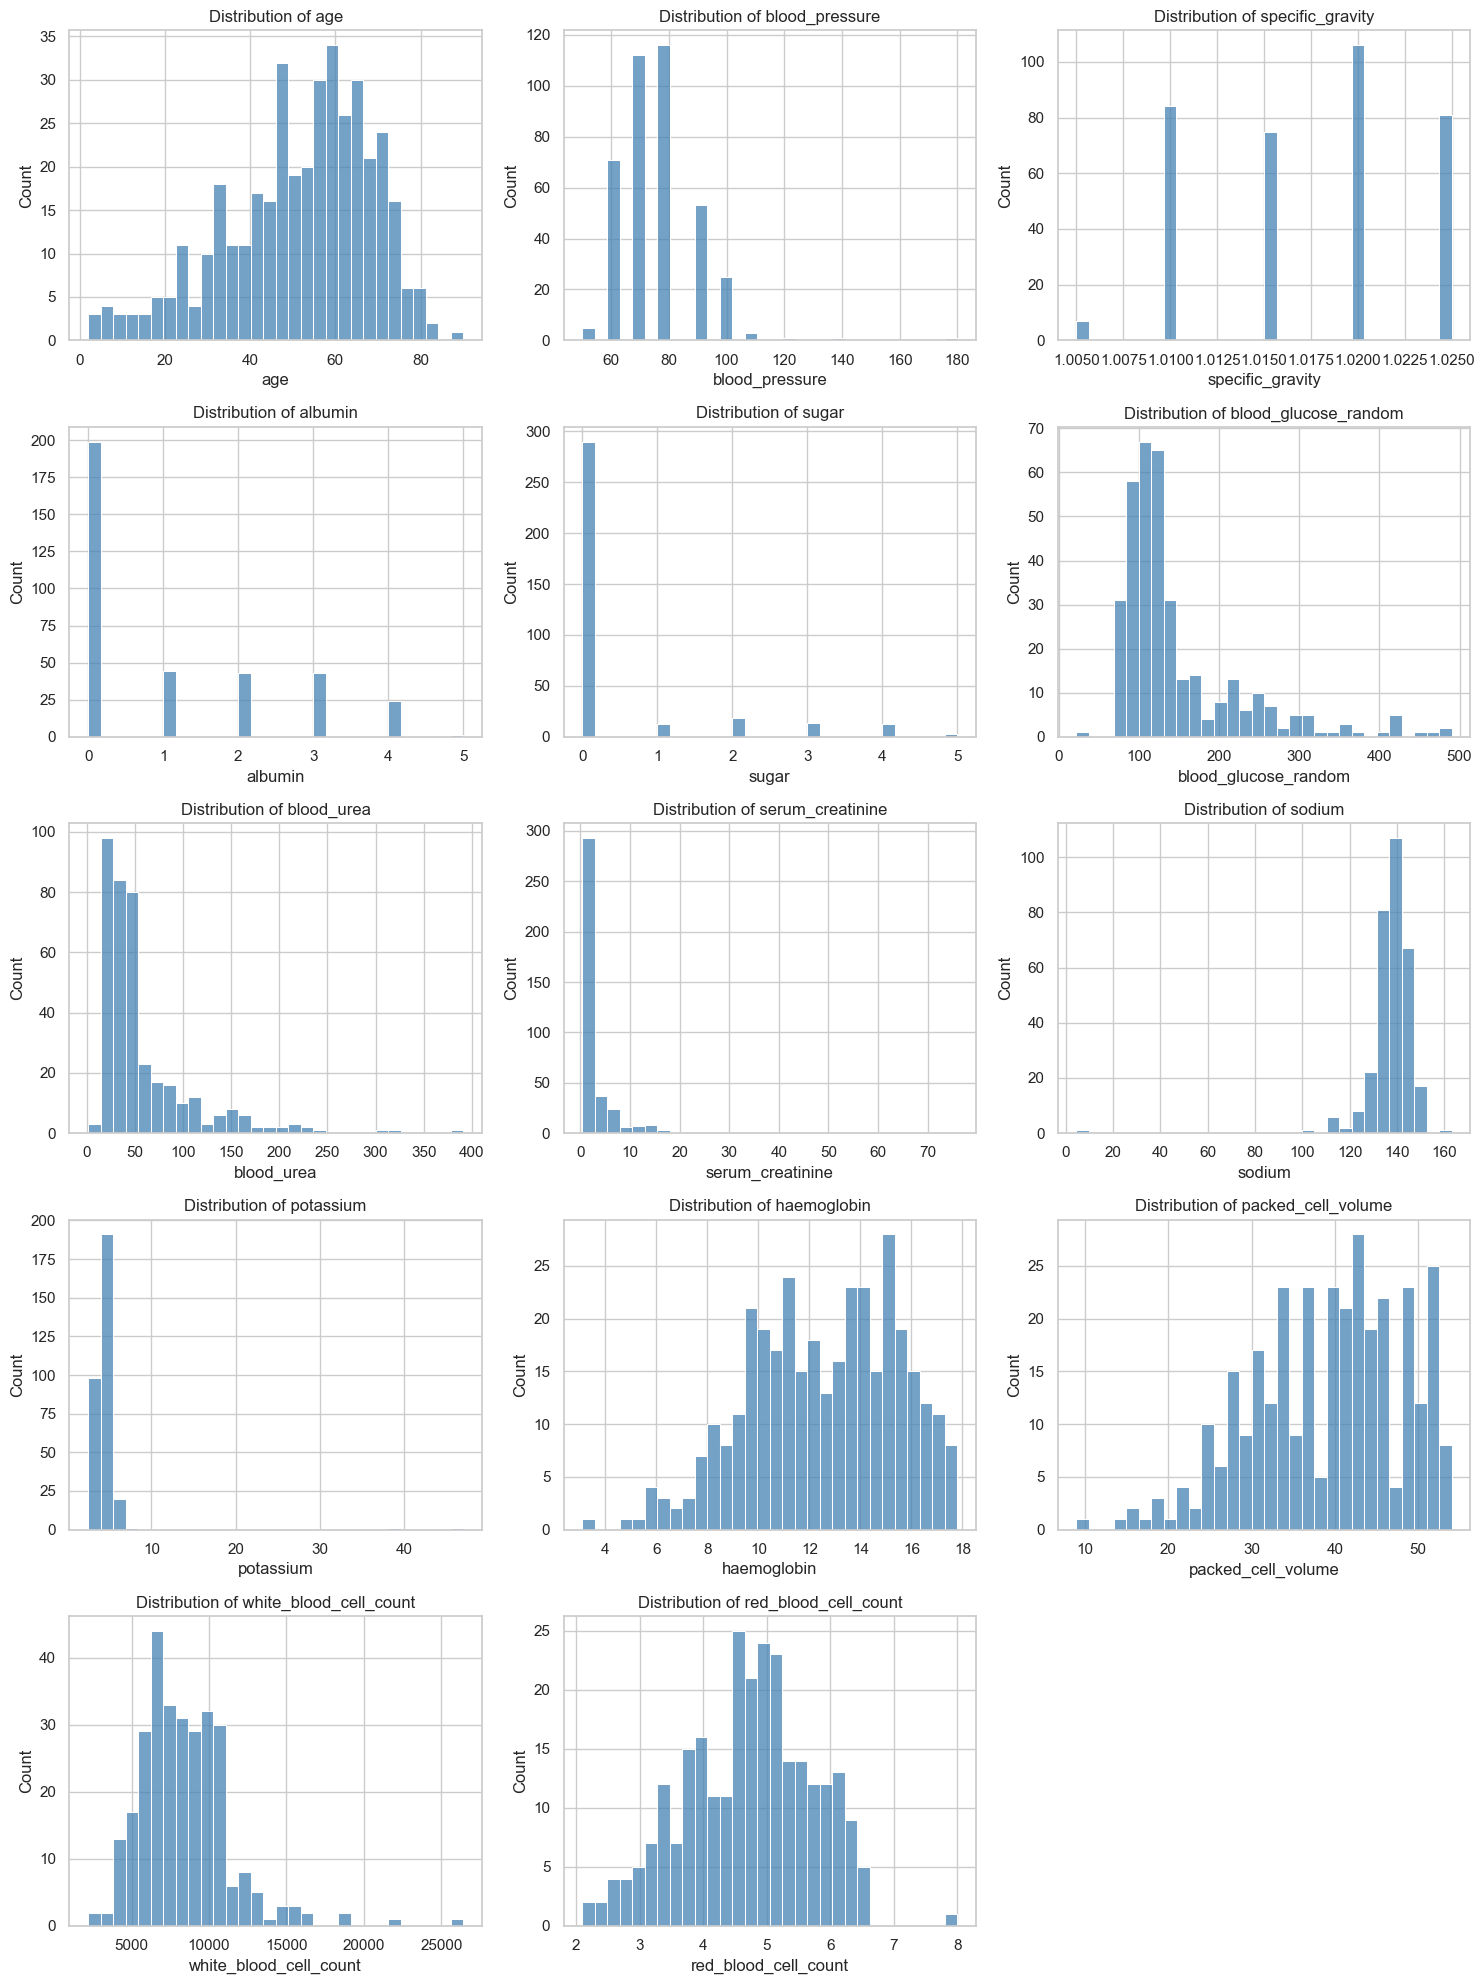

In [13]:
# Select only numeric columns (int64 or float64)
num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Plot style
sns.set(style="whitegrid")

# Determine grid size
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

# Plot each numeric feature
for i, col in enumerate(num_features):
    sns.histplot(df[col].dropna(), bins=30, kde=False, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [14]:
(df[num_features] < 0).sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

We dont see any negative values. But there are some potential issues with outlier on blood pressure, serum_creatine and potassium. Without domain specific knowledge I will not be adjusting them as they could be valid values.

## Pre-split prep for categorical data

In order to perform the dimensionality reduction method PCA, all values need to be in numeric form. Looking the unique value for each categorical variable below, we can see that they are infact binary with the addition of a nan value. We can keep the nan for now (sorting it out later post split to avoid data leakage), and assign the categoric variables to a 0 or a 1.

In [15]:
# Select object columns
obj_cols = df.select_dtypes(include='object').columns

# Print unique values for each object column
for col in obj_cols:
    print(f"{col}: {df[col].unique()}")

red_blood_cells: [nan 'normal' 'abnormal']
pus_cell: ['normal' 'abnormal' nan]
pus_cell_clumps: ['notpresent' 'present' nan]
bacteria: ['notpresent' 'present' nan]
hypertension: ['yes' 'no' nan]
diabetes_mellitus: ['yes' 'no' nan]
coronary_artery_disease: ['no' 'yes' nan]
appetite: ['good' 'poor' nan]
peda_edema: ['no' 'yes' nan]
anemia: ['no' 'yes' nan]
class: ['ckd' 'notckd']


In [16]:
# Mapping dictionary for each column
bool_mappings = {
    'red_blood_cells': {'normal': 1, 'abnormal': 0},
    'pus_cell': {'normal': 1, 'abnormal': 0},
    'pus_cell_clumps': {'present': 1, 'notpresent': 0},
    'bacteria': {'present': 1, 'notpresent': 0},
    'hypertension': {'yes': 1, 'no': 0},
    'diabetes_mellitus': {'yes': 1, 'no': 0},
    'coronary_artery_disease': {'yes': 1, 'no': 0},
    'appetite': {'good': 1, 'poor': 0},
    'peda_edema': {'yes': 1, 'no': 0},
    'anemia': {'yes': 1, 'no': 0},
    'class': {'ckd': 1, 'notckd': 0}  # target
}

# Apply the mapping to each column
for col, mapping in bool_mappings.items():
    df[col] = df[col].map(mapping)

In [ ]:
# Feature correlation heatmap
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Show top correlations (excluding diagonal)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove diagonal
top_corr = corr_pairs.abs().sort_values(ascending=False).head(10)
print("\nTop 10 Feature Correlations:")
print("="*50)
for (feat1, feat2), corr_val in top_corr.items():
    actual_val = corr_matrix.loc[feat1, feat2]
    print(f"{feat1:20s} <-> {feat2:20s} : {actual_val:6.3f}")

### Feature Correlation Analysis

**Purpose**: Understand relationships between features before PCA

**Inputs**: Numeric features from the dataset

**Process**: Calculate correlation matrix and visualize with heatmap

**Outputs**: Heatmap showing feature correlations (-1 to +1)

In [17]:
# Calculate eGFR (estimated Glomerular Filtration Rate)
# Note: This uses the simplified MDRD equation without gender/race modifiers
df['egfr'] = 175 * (df['serum_creatinine'] ** -1.154) * (df['age'] ** -0.203)

def classify_stage(egfr_value):
    """Classify CKD stage based on eGFR"""
    if pd.isna(egfr_value):
        return np.nan
    if egfr_value >= 90:
        return 1  # Normal/high
    elif egfr_value >= 60:
        return 2  # Mild reduction
    elif egfr_value >= 30:
        return 3  # Moderate reduction
    elif egfr_value >= 15:
        return 4  # Severe reduction
    else:
        return 5  # Kidney failure

# Create stage column
df['stage'] = df['egfr'].apply(classify_stage)

# Display stage distribution
print("CKD Stage Distribution:")
print(df['stage'].value_counts().sort_index())
print(f"\nPercentage distribution:")
print(df['stage'].value_counts(normalize=True).sort_index() * 100)

CKD Stage Distribution:
stage
1.0    102
2.0     84
3.0     74
4.0     52
5.0     62
Name: count, dtype: int64

Percentage distribution:
stage
1.0    27.272727
2.0    22.459893
3.0    19.786096
4.0    13.903743
5.0    16.577540
Name: proportion, dtype: float64


In [ ]:
# Visualize stage distribution and eGFR by stage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stage distribution
stage_counts = df['stage'].value_counts().sort_index()
bars = axes[0].bar(stage_counts.index, stage_counts.values, color=['green', 'blue', 'orange', 'red', 'darkred'])
axes[0].set_xlabel('CKD Stage')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('CKD Stage Distribution')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')

# eGFR distribution by stage
stage_data = [df[df['stage'] == stage]['egfr'].dropna() for stage in sorted(df['stage'].dropna().unique())]
bp = axes[1].boxplot(stage_data, labels=[f'Stage {int(s)}' for s in sorted(df['stage'].dropna().unique())],
                      patch_artist=True)

# Color boxplots
colors = ['green', 'blue', 'orange', 'red', 'darkred']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_xlabel('CKD Stage')
axes[1].set_ylabel('eGFR (mL/min/1.73m²)')
axes[1].set_title('eGFR Distribution by CKD Stage')
axes[1].grid(axis='y', alpha=0.3)

# Add reference lines for stage boundaries
axes[1].axhline(y=90, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[1].axhline(y=60, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[1].axhline(y=30, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[1].axhline(y=15, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

### CKD Stage Distribution Visualization

**Purpose**: Visualize the distribution of CKD stages and eGFR values

**Inputs**: 
- `df['stage']`: CKD stage classifications (1-5)
- `df['egfr']`: Calculated eGFR values

**Process**:
1. Create stage distribution bar plot with counts
2. Create eGFR distribution boxplot by stage
3. Show class imbalance for modeling consideration

**Outputs**: 
- Bar chart showing sample count per stage
- Boxplot showing eGFR range per stage

## CKD Stage Classification

Instead of binary classification (CKD/not CKD), we'll calculate the **estimated Glomerular Filtration Rate (eGFR)** and classify patients into **CKD stages 1-5** based on kidney function.

The eGFR formula (MDRD equation):
$$\text{eGFR} = 175 \times (\text{SerumCreatinine})^{-1.154} \times (\text{Age})^{-0.203}$$

CKD Stages:
- **Stage 1**: eGFR ≥ 90 (Normal/high kidney function)
- **Stage 2**: eGFR 60-89 (Mild reduction)
- **Stage 3**: eGFR 30-59 (Moderate reduction)
- **Stage 4**: eGFR 15-29 (Severe reduction)
- **Stage 5**: eGFR < 15 (Kidney failure)

## Train Test Split

We will create three subsets:
- **Training set (60%)**: For model training
- **Validation set (20%)**: For hyperparameter tuning and model selection
- **Test set (20%)**: For final evaluation (completely held out)

Note that `stratify=y` preserves the class proportions across all splits.

In [18]:
# Separate features and target
# Drop 'class', 'stage', and 'egfr' from features
# - 'stage' is our target variable
# - 'egfr' should not be used as a feature (it's derived from serum_creatinine and age)
# - 'class' was the old binary target

# First, remove rows where stage is NaN (missing serum_creatinine or age)
df_clean = df.dropna(subset=['stage'])
print(f"Removed {len(df) - len(df_clean)} rows with missing stage values")
print(f"Remaining samples: {len(df_clean)}")

X = df_clean.drop(['class', 'stage', 'egfr'], axis=1)
y = df_clean['stage']  # target: CKD stages 1-5

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: divide remaining data into train (75% of 80% = 60%) and validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of total
    random_state=42,
    stratify=y_temp
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass distribution in training set: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Class distribution in validation set: {y_val.value_counts(normalize=True).to_dict()}")
print(f"Class distribution in test set: {y_test.value_counts(normalize=True).to_dict()}")

Removed 26 rows with missing stage values
Remaining samples: 374
Training set size: 224 (59.9%)
Validation set size: 75 (20.1%)
Test set size: 75 (20.1%)

Class distribution in training set: {1.0: 0.27232142857142855, 2.0: 0.22321428571428573, 3.0: 0.19642857142857142, 5.0: 0.16517857142857142, 4.0: 0.14285714285714285}
Class distribution in validation set: {1.0: 0.26666666666666666, 2.0: 0.22666666666666666, 3.0: 0.2, 5.0: 0.17333333333333334, 4.0: 0.13333333333333333}
Class distribution in test set: {1.0: 0.28, 2.0: 0.22666666666666666, 3.0: 0.2, 5.0: 0.16, 4.0: 0.13333333333333333}


In [ ]:
# Visualize class distribution across splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart showing counts
stages = sorted(y_train.unique())
train_counts = [sum(y_train == s) for s in stages]
val_counts = [sum(y_val == s) for s in stages]
test_counts = [sum(y_test == s) for s in stages]

x = np.arange(len(stages))
width = 0.25

axes[0].bar(x - width, train_counts, width, label='Train (60%)', color='steelblue', alpha=0.8)
axes[0].bar(x, val_counts, width, label='Validation (20%)', color='orange', alpha=0.8)
axes[0].bar(x + width, test_counts, width, label='Test (20%)', color='green', alpha=0.8)

axes[0].set_xlabel('CKD Stage')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Sample Distribution Across Train/Val/Test Splits')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Stage {int(s)}' for s in stages])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Proportions (percentage)
train_props = y_train.value_counts(normalize=True).sort_index() * 100
val_props = y_val.value_counts(normalize=True).sort_index() * 100
test_props = y_test.value_counts(normalize=True).sort_index() * 100

axes[1].bar(x - width, train_props.values, width, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x, val_props.values, width, label='Validation', color='orange', alpha=0.8)
axes[1].bar(x + width, test_props.values, width, label='Test', color='green', alpha=0.8)

axes[1].set_xlabel('CKD Stage')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Class Proportion Across Splits (Should be Similar)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Stage {int(s)}' for s in stages])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Train/Validation/Test Split Visualization

**Purpose**: Verify balanced class distribution across data splits

**Inputs**: `y_train`, `y_val`, `y_test` - Stage labels for each split

**Process**: Compare class proportions across all three splits

**Outputs**: Grouped bar chart showing stage distribution in each split

Now we do out post split transformations...

Imputation of the missing values and scaling. We utilise the handy scikit pipeline!

In [19]:
num_cols = [
    'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
    'blood_glucose_random', 'blood_urea', 'serum_creatinine',
    'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume',
    'white_blood_cell_count', 'red_blood_cell_count'
]

# Boolean columns (already mapped to 0/1)
bool_cols = [
    'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
    'appetite', 'peda_edema', 'anemia'
]

# Target column (now using CKD stages instead of binary classification)
target_col = 'stage'

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

bool_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('bool', bool_pipeline, bool_cols)
])

Setting n_components to 0.95 means that during the PCA we will combine parameters while still retaining 95% of the original variance.

In [20]:
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42))  # keep 95% variance
])

In [21]:
# Transform all three sets
X_train_processed = pca_pipeline.fit_transform(X_train)
X_val_processed = pca_pipeline.transform(X_val)
X_test_processed = pca_pipeline.transform(X_test)

print("Training set shape after PCA:", X_train_processed.shape)
print("Validation set shape after PCA:", X_val_processed.shape)
print("Test set shape after PCA:", X_test_processed.shape)

Training set shape after PCA: (224, 20)
Validation set shape after PCA: (75, 20)
Test set shape after PCA: (75, 20)


Excluding the target variable, we originally had 24 input features. After applying PCA (with 95% variance retention), the dataset was reduced to 20 principal components.

It's important to note that these principal components are not the original features themselves, but rather new, orthogonal axes that capture the maximum variance in the data. In other words, PCA doesn't "select" 20 of the original features; it creates 20 transformed features that are linear combinations of the original ones.

### PCA Variance Explained

**Purpose**: Visualize how much information each principal component captures

**Inputs**: 
- `pca.explained_variance_ratio_`: Variance explained by each PC

**Process**:
1. Plot individual variance per component (scree plot)
2. Plot cumulative variance to show 95% threshold
3. Show contribution breakdown

**Outputs**: 
- Scree plot with cumulative variance line
- Bar chart of individual PC contributions

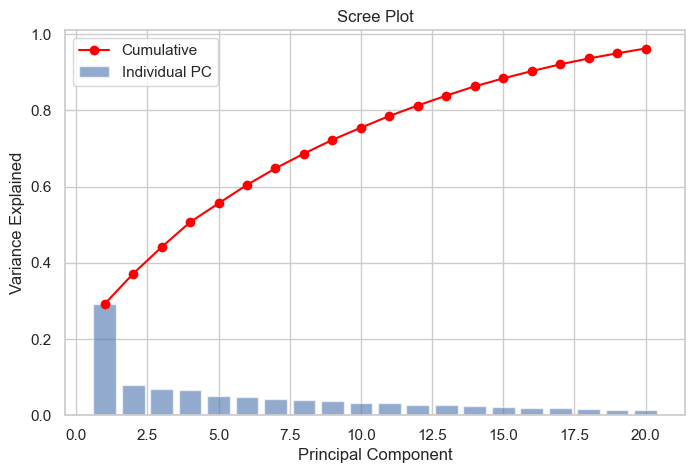

In [ ]:
pca = pca_pipeline.named_steps['pca']
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, color='steelblue', label='Individual PC')
axes[0].plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', color='red', linewidth=2, label='Cumulative')
axes[0].axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% Threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot - Variance Explained by Each PC')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Component contributions
axes[1].bar(range(1, len(explained_var)+1), explained_var * 100, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title(f'Individual PC Contributions (Total: {len(explained_var)} components)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Retained {len(explained_var)} components explaining {cumulative_var[-1]*100:.2f}% of variance")

## Implementation of a classifcation model

## Cross-Validation Analysis

Before training final models, we'll use cross-validation on the training set to get robust performance estimates and compare different algorithms.

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models to compare with class_weight='balanced' where applicable
# This automatically adjusts weights inversely proportional to class frequencies
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        max_iter=1000, 
        class_weight='balanced',
        multi_class='multinomial'  # For multi-class (stages 1-5)
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        random_state=42
    ),  # No class_weight parameter
    'SVM': SVC(
        kernel='rbf', 
        probability=True, 
        random_state=42, 
        class_weight='balanced'
    ),
    'Naive Bayes': GaussianNB(),  # No class_weight parameter
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)  # No class_weight parameter
}

# Store cross-validation results
cv_results = {}

print("Cross-Validation Results (5-Fold):")
print("-" * 60)

for name, model in models.items():
    # Perform cross-validation
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    
    print(f"{name:25s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")
    print(f"                          | Fold scores: {scores}")

print("-" * 60)

Cross-Validation Results (5-Fold):
------------------------------------------------------------
Logistic Regression       | Mean: 0.5089 | Std: 0.0204
                          | Fold scores: [0.53333333 0.48888889 0.48888889 0.53333333 0.5       ]


c:\GIT\CDK\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\GIT\CDK\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\GIT\CDK\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\GIT\CDK\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8

Random Forest             | Mean: 0.4687 | Std: 0.0499
                          | Fold scores: [0.48888889 0.55555556 0.42222222 0.42222222 0.45454545]
Gradient Boosting         | Mean: 0.4382 | Std: 0.0989
                          | Fold scores: [0.44444444 0.48888889 0.35555556 0.31111111 0.59090909]
SVM                       | Mean: 0.4466 | Std: 0.0265
                          | Fold scores: [0.44444444 0.46666667 0.44444444 0.4        0.47727273]
Naive Bayes               | Mean: 0.5131 | Std: 0.0608
                          | Fold scores: [0.62222222 0.53333333 0.48888889 0.46666667 0.45454545]
Gradient Boosting         | Mean: 0.4382 | Std: 0.0989
                          | Fold scores: [0.44444444 0.48888889 0.35555556 0.31111111 0.59090909]
SVM                       | Mean: 0.4466 | Std: 0.0265
                          | Fold scores: [0.44444444 0.46666667 0.44444444 0.4        0.47727273]
Naive Bayes               | Mean: 0.5131 | Std: 0.0608
                          |

C:\Users\RickReyJim\AppData\Local\Temp\ipykernel_8564\1523962113.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


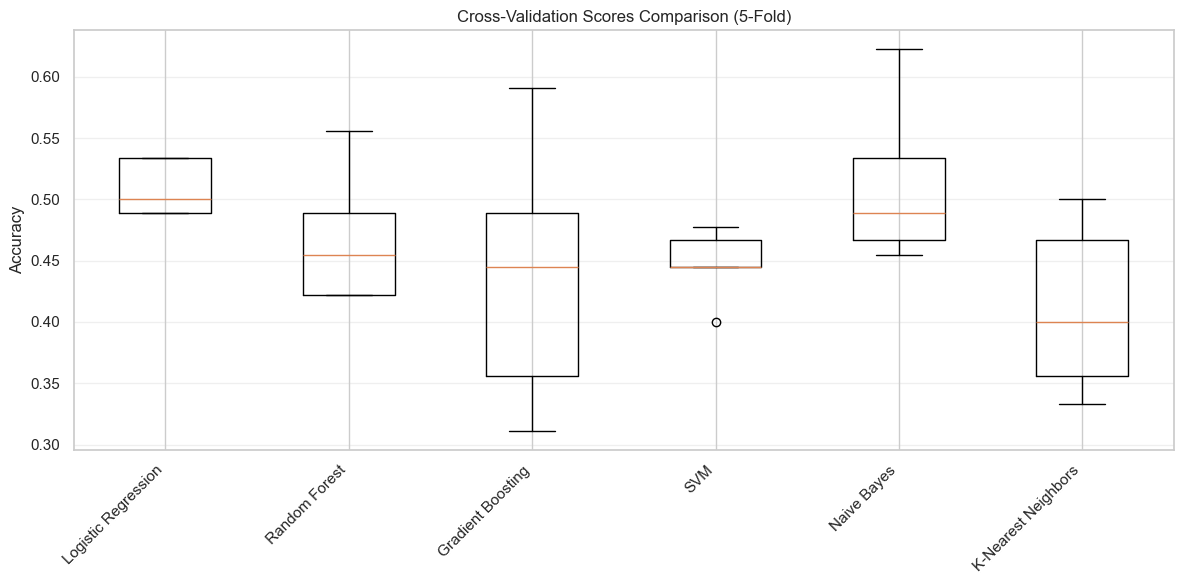

In [24]:
# Visualize cross-validation results
plt.figure(figsize=(12, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores Comparison (5-Fold)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Model Training and Validation

Now we'll train all models on the training set and evaluate them on the validation set.

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train all models and evaluate on validation set
val_results = {}

print("Validation Set Results:")
print("-" * 80)
print(f"{'Model':<25s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1-Score':<12s}")
print("-" * 80)

for name, model in models.items():
    # Train on training set
    model.fit(X_train_processed, y_train)
    
    # Predict on validation set
    y_val_pred = model.predict(X_val_processed)
    
    # Calculate metrics (use 'weighted' average for multi-class)
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    
    val_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'model': model
    }
    
    print(f"{name:<25s} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("-" * 80)

# Find best model based on F1-score
best_model_name = max(val_results, key=lambda x: val_results[x]['f1_score'])
print(f"\nBest model based on validation F1-score: {best_model_name}")

c:\GIT\CDK\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Validation Set Results:
--------------------------------------------------------------------------------
Model                     Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Logistic Regression       0.6400       0.6396       0.6400       0.6329      
Random Forest             0.4667       0.4356       0.4667       0.4453      
Random Forest             0.4667       0.4356       0.4667       0.4453      
Gradient Boosting         0.4400       0.4111       0.4400       0.4220      
SVM                       0.5067       0.5025       0.5067       0.4899      
Naive Bayes               0.4667       0.4708       0.4667       0.4613      
K-Nearest Neighbors       0.4667       0.4492       0.4667       0.4554      
--------------------------------------------------------------------------------

Best model based on validation F1-score: Logistic Regression
Gradient Boosting         0.4400       0.4111  

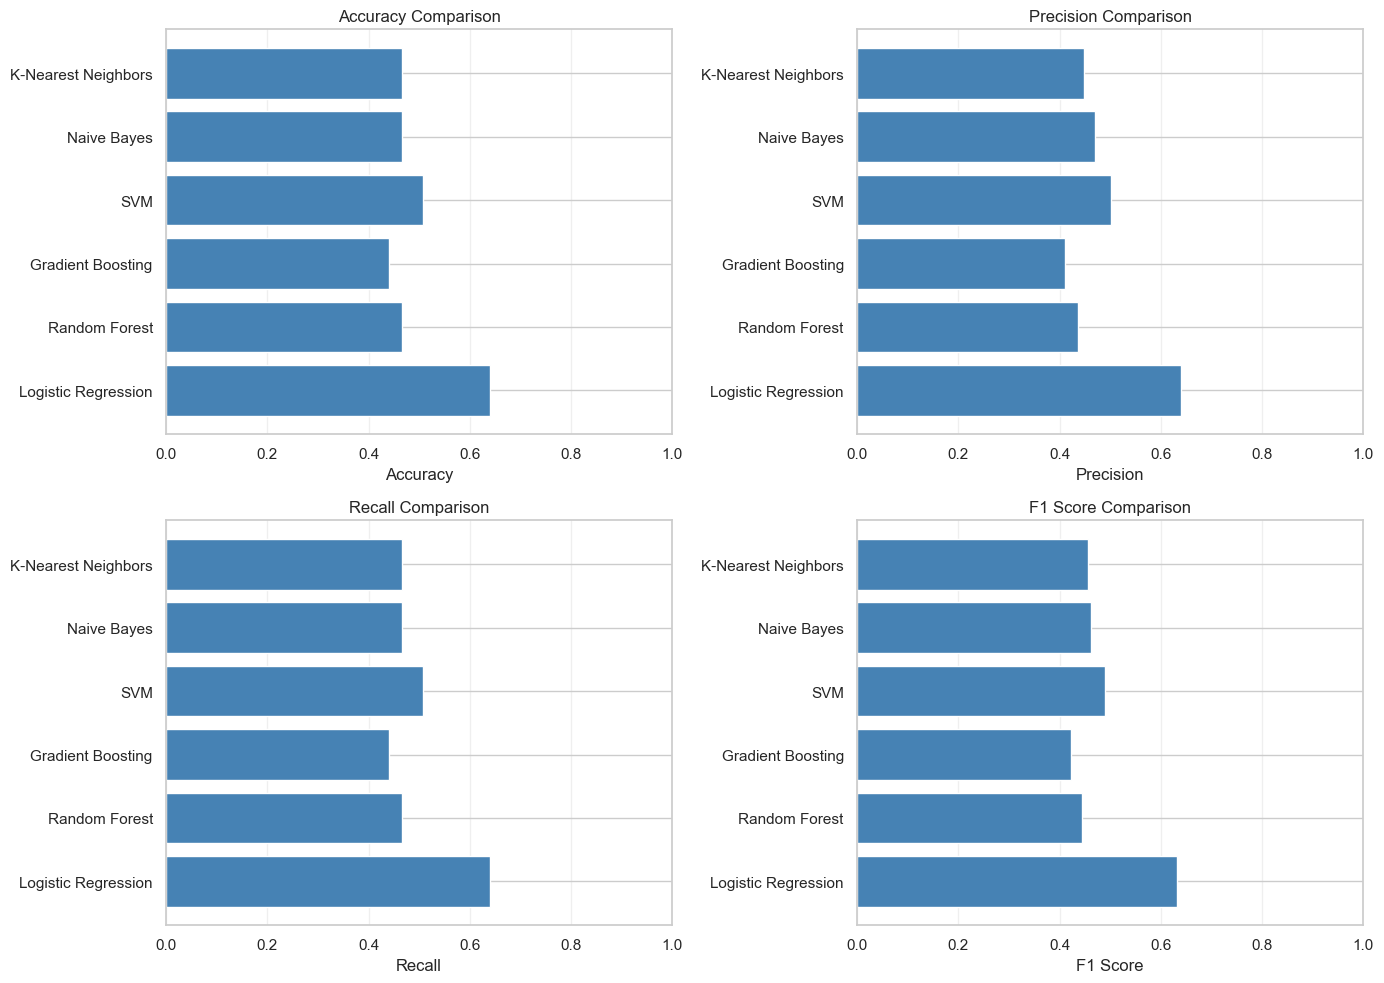

In [26]:
# Visualize validation results comparison
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    values = [val_results[model][metric] for model in val_results.keys()]
    axes[idx].barh(list(val_results.keys()), values, color='steelblue')
    axes[idx].set_xlabel(metric.replace('_', ' ').title())
    axes[idx].set_title(f'{metric.replace("_", " ").title()} Comparison')
    axes[idx].set_xlim([0, 1])
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance for tree-based models
# Note: These show importance in the PCA-transformed space, not original features
tree_models = {
    'Random Forest': val_results.get('Random Forest', {}).get('model'),
    'Gradient Boosting': val_results.get('Gradient Boosting', {}).get('model')
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (name, model) in enumerate(tree_models.items()):
    if model is not None and hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:15]  # Top 15
        
        axes[idx].barh(range(len(indices)), importances[indices], color='steelblue', alpha=0.7)
        axes[idx].set_yticks(range(len(indices)))
        axes[idx].set_yticklabels([f'PC{i+1}' for i in indices])
        axes[idx].set_xlabel('Importance')
        axes[idx].set_title(f'Feature Importance - {name}')
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print top 5 for each model
print("\nTop 5 Most Important Principal Components:")
print("="*60)
for name, model in tree_models.items():
    if model is not None and hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:5]
        print(f"\n{name}:")
        for i, idx in enumerate(indices, 1):
            print(f"  {i}. PC{idx+1}: {importances[idx]:.4f}")

### Feature Importance Analysis

**Purpose**: Understand which features contribute most to predictions

**Inputs**: 
- Trained Random Forest and Gradient Boosting models
- Original feature names

**Process**:
1. Extract feature importances from tree-based models
2. Map back to original features (before PCA)
3. Visualize top contributing features

**Outputs**: Horizontal bar charts showing top 15 important features

## Final Model Evaluation on Test Set

Now we'll evaluate all models on the test set (which has not been used until now) to get unbiased performance estimates.

In [27]:
# Evaluate all models on test set
test_results = {}

print("Test Set Results (Final Evaluation):")
print("-" * 80)
print(f"{'Model':<25s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1-Score':<12s}")
print("-" * 80)

for name, data in val_results.items():
    model = data['model']
    
    # Predict on test set
    y_test_pred = model.predict(X_test_processed)
    
    # Calculate metrics (use 'weighted' average for multi-class)
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    
    test_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'predictions': y_test_pred,
        'model': model
    }
    
    print(f"{name:<25s} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("-" * 80)

# Find best model on test set
best_test_model_name = max(test_results, key=lambda x: test_results[x]['f1_score'])
print(f"\nBest model on test set (F1-score): {best_test_model_name}")

Test Set Results (Final Evaluation):
--------------------------------------------------------------------------------
Model                     Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Logistic Regression       0.6267       0.6312       0.6267       0.6284      
Random Forest             0.5867       0.5812       0.5867       0.5723      
Gradient Boosting         0.5200       0.5144       0.5200       0.5145      
SVM                       0.5067       0.5115       0.5067       0.4966      
Naive Bayes               0.4800       0.4807       0.4800       0.4794      
K-Nearest Neighbors       0.5200       0.5131       0.5200       0.5088      
--------------------------------------------------------------------------------

Best model on test set (F1-score): Logistic Regression


## Detailed Analysis of Best Model

**Purpose**: Deep dive into best model's performance

**Inputs**: 
- `best_model`: Best performing model from test results
- `y_test`, `y_pred`: Actual and predicted stages

**Process**:
1. Generate classification report (precision, recall, F1 per stage)
2. Create confusion matrix
3. Calculate per-stage accuracy

**Outputs**: 
- Classification metrics table
- Confusion matrix
- Per-stage performance breakdown

In [ ]:
# Get the best model
best_model = test_results[best_test_model_name]['model']
y_pred = test_results[best_test_model_name]['predictions']

print(f"Detailed Analysis for Best Model: {best_test_model_name}")
print("=" * 80)

# -----------------------------
# 1. Classification report (for multi-class)
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Stage {i}' for i in sorted(y_test.unique())]))

# -----------------------------
# 2. Confusion matrix
# -----------------------------
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Per-class accuracy
print("\nPer-Stage Accuracy:")
print("="*40)
for i, stage in enumerate(sorted(y_test.unique())):
    stage_mask = y_test == stage
    stage_acc = (y_pred[stage_mask] == stage).sum() / stage_mask.sum()
    print(f"Stage {int(stage)}: {stage_acc*100:.1f}% ({(y_pred[stage_mask] == stage).sum()}/{stage_mask.sum()} correct)")

Detailed Analysis for Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

   Stage 1.0       0.65      0.62      0.63        21
   Stage 2.0       0.50      0.53      0.51        17
   Stage 3.0       0.64      0.60      0.62        15
   Stage 4.0       0.45      0.50      0.48        10
   Stage 5.0       0.92      0.92      0.92        12

    accuracy                           0.63        75
   macro avg       0.63      0.63      0.63        75
weighted avg       0.63      0.63      0.63        75


Confusion Matrix:
[[13  8  0  0  0]
 [ 6  9  1  1  0]
 [ 1  0  9  5  0]
 [ 0  0  4  5  1]
 [ 0  1  0  0 11]]


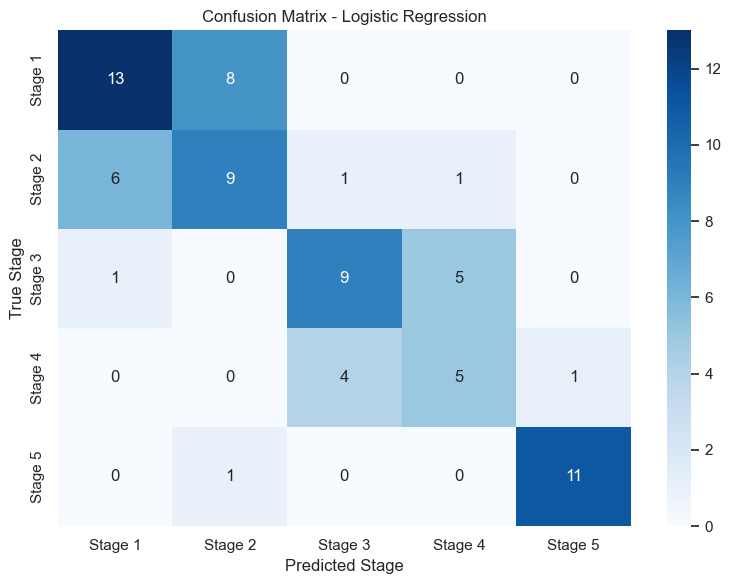

In [ ]:
# Compute confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)

# Get unique stages for labels
stages = sorted(y_test.unique())
stage_labels = [f'Stage {int(s)}' for s in stages]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix with counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=stage_labels,
            yticklabels=stage_labels,
            ax=axes[0])
axes[0].set_ylabel('True Stage')
axes[0].set_xlabel('Predicted Stage')
axes[0].set_title(f'Confusion Matrix - {best_test_model_name}\n(Counts)')

# Plot 2: Confusion Matrix with percentages (normalized by true label)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues', cbar=True,
            xticklabels=stage_labels,
            yticklabels=stage_labels,
            ax=axes[1])
axes[1].set_ylabel('True Stage')
axes[1].set_xlabel('Predicted Stage')
axes[1].set_title(f'Confusion Matrix - {best_test_model_name}\n(Row-wise Percentages)')

plt.tight_layout()
plt.show()

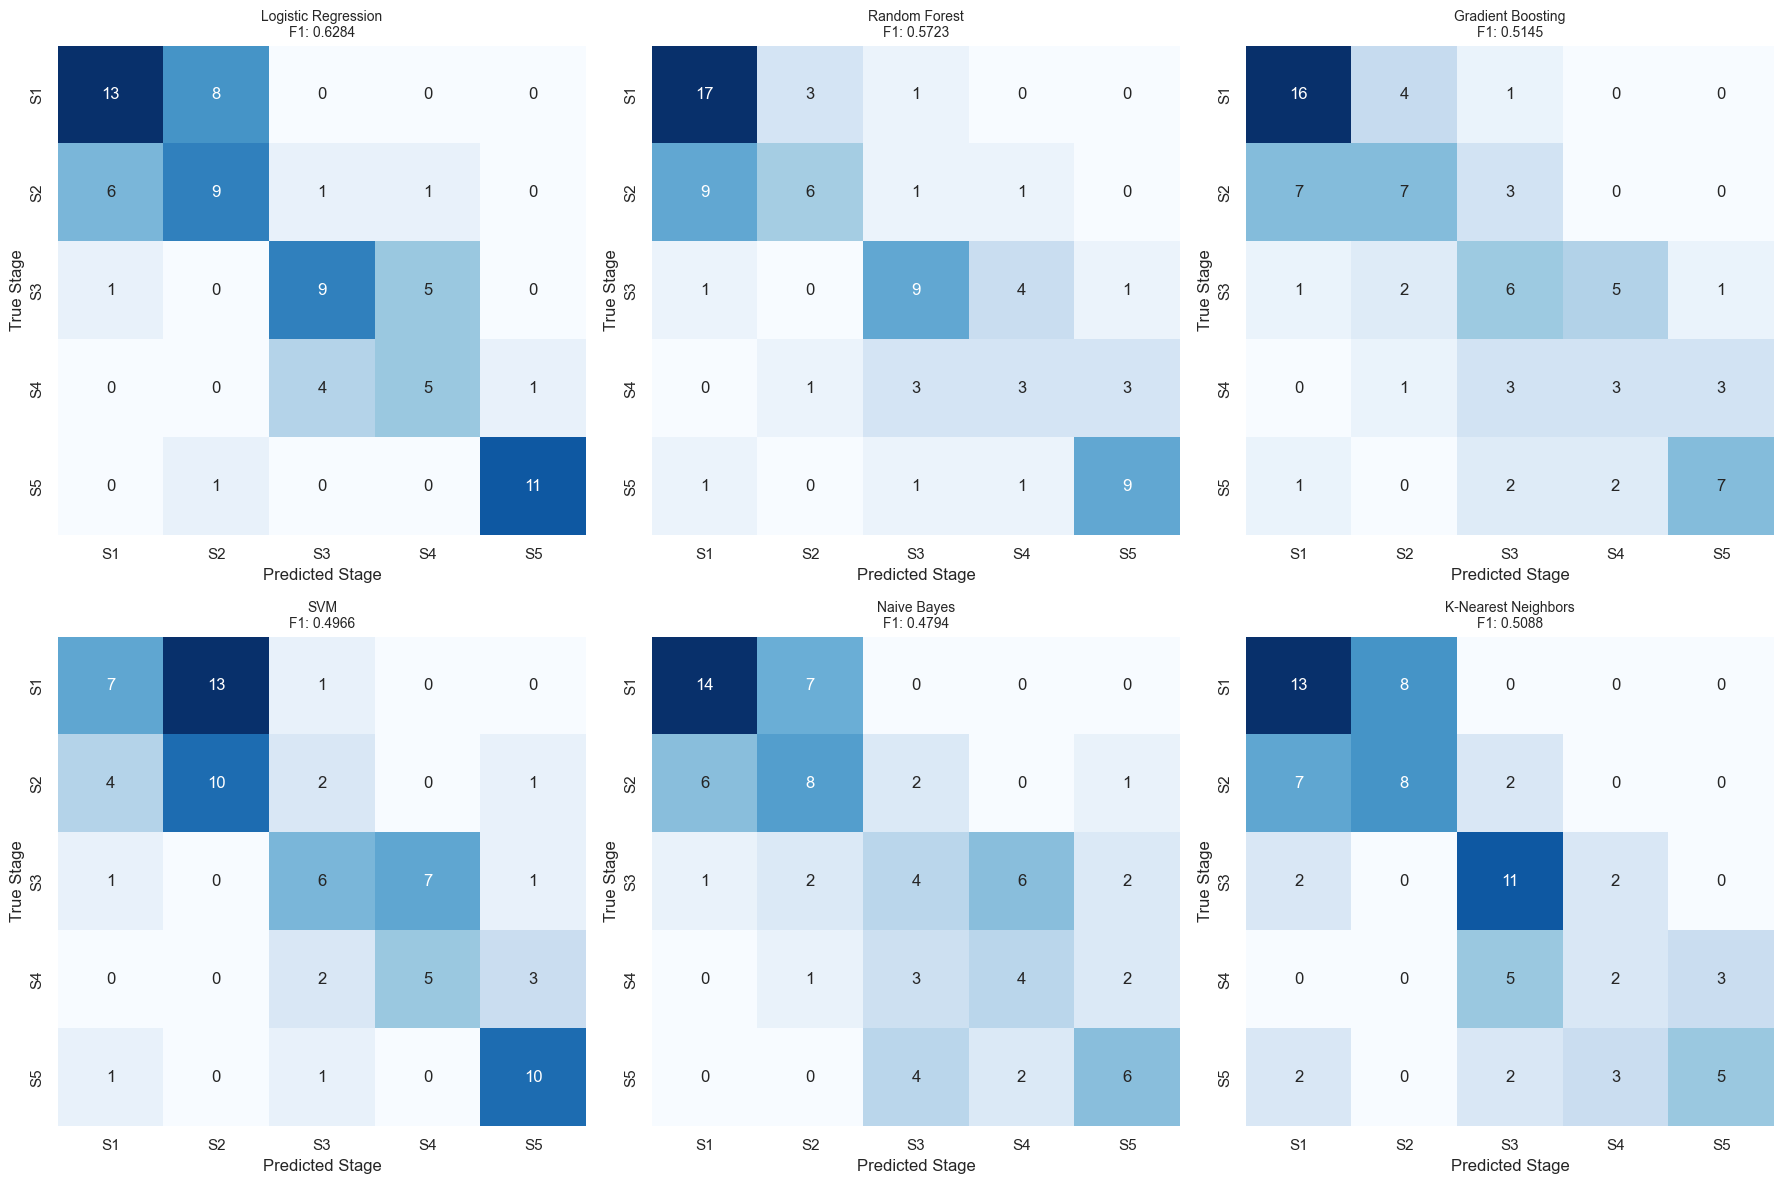

In [ ]:
# Compare confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Get unique stages for labels
stages = sorted(y_test.unique())
stage_labels = [f'S{int(s)}' for s in stages]  # Short labels for space

for idx, (name, data) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    
    # Normalize by row (true label)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=stage_labels,
                yticklabels=stage_labels,
                vmin=0, vmax=1,
                ax=axes[idx])
    axes[idx].set_ylabel('True Stage')
    axes[idx].set_xlabel('Predicted Stage')
    axes[idx].set_title(f'{name}\nF1: {data["f1_score"]:.4f} | Acc: {data["accuracy"]:.4f}', fontsize=10)

plt.suptitle('Confusion Matrices Comparison - All Models (Normalized)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

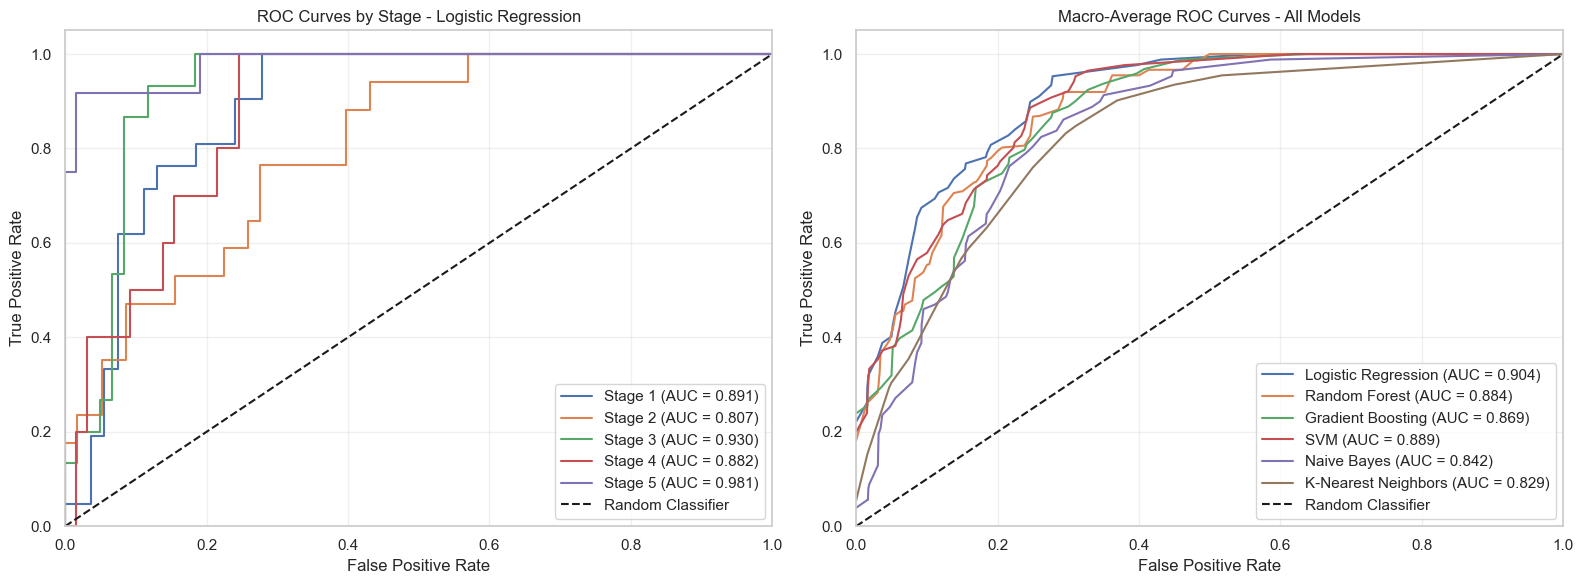

In [31]:
# ROC Curves for multi-class (One-vs-Rest approach)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC
stages = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=stages)
n_classes = len(stages)

# Plot ROC curve for best model
best_model = test_results[best_test_model_name]['model']
y_score = best_model.predict_proba(X_test_processed)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: ROC curves for each stage (best model only)
for i, stage in enumerate(stages):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'Stage {int(stage)} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curves by Stage - {best_test_model_name}')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Plot 2: Macro-average ROC for all models
for name, data in test_results.items():
    model = data['model']
    y_score = model.predict_proba(X_test_processed)
    
    # Compute macro-average ROC curve and ROC area
    fpr = dict()
    tpr = dict()
    roc_auc_dict = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc_dict[i] = auc(fpr[i], tpr[i])
    
    # Compute macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    macro_auc = auc(all_fpr, mean_tpr)
    axes[1].plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Macro-Average ROC Curves - All Models')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Comprehensive model comparison
metrics_comparison = ['accuracy', 'precision', 'recall', 'f1_score']
model_names = list(test_results.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_comparison):
    values = [test_results[model][metric] for model in model_names]
    colors = ['gold' if model == best_test_model_name else 'steelblue' for model in model_names]
    
    axes[idx].barh(model_names, values, color=colors, alpha=0.8)
    axes[idx].set_xlabel(metric.replace('_', ' ').title())
    axes[idx].set_title(f'{metric.replace("_", " ").title()} Comparison on Test Set')
    axes[idx].set_xlim([0, 1])
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(values):
        axes[idx].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle(f'Model Performance Comparison (Best: {best_test_model_name})', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### Model Performance Comparison

**Purpose**: Compare all models across multiple metrics

**Inputs**: `test_results` - Performance metrics for all 6 models

**Process**: Create comprehensive comparison visualization

**Outputs**: Multi-panel chart comparing accuracy, precision, recall, F1-score

Interesting to add: The below  2D visualization of the data in PCA space (first two PCs), labeled by class. It tells us whether your classes have some visual separation in those components.

With our results, we can see that the overall structure is consistent across splits.

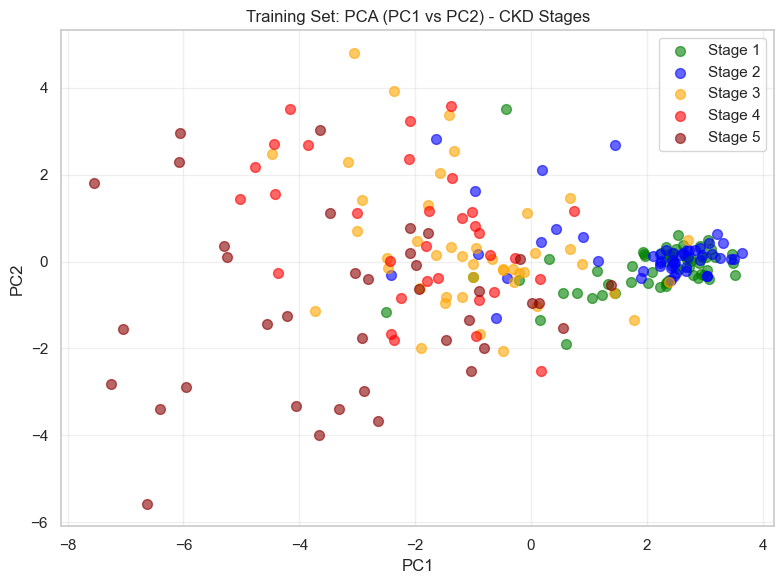

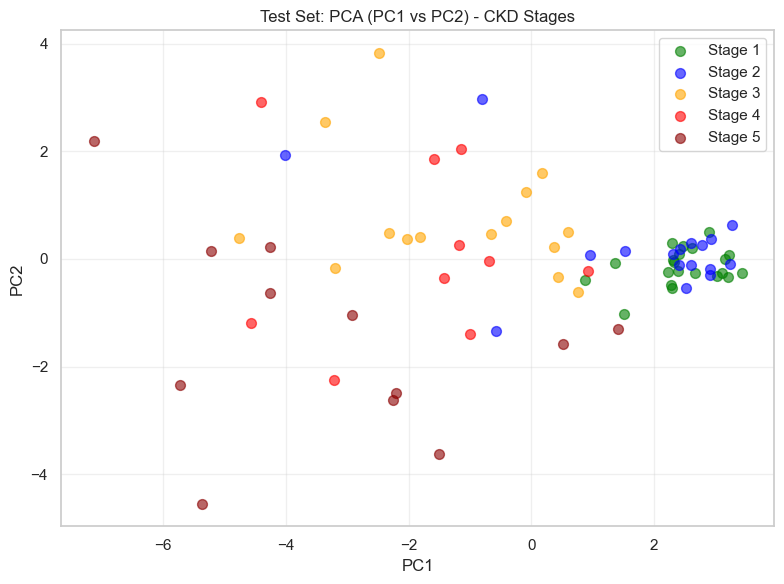

In [32]:
# Get the first two principal components from your PCA pipeline
X_train_2d = X_train_processed[:, :2]
X_test_2d = X_test_processed[:, :2]

# Define colors for each stage
stage_colors = {1: 'green', 2: 'blue', 3: 'orange', 4: 'red', 5: 'darkred'}

# Plot training data
plt.figure(figsize=(8, 6))
for stage in sorted(y_train.unique()):
    mask = y_train == stage
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], 
                c=stage_colors.get(stage, 'gray'),
                label=f'Stage {int(stage)}', 
                alpha=0.6, 
                s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Training Set: PCA (PC1 vs PC2) - CKD Stages')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot test data
plt.figure(figsize=(8, 6))
for stage in sorted(y_test.unique()):
    mask = y_test == stage
    plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], 
                c=stage_colors.get(stage, 'gray'),
                label=f'Stage {int(stage)}', 
                alpha=0.6, 
                s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Test Set: PCA (PC1 vs PC2) - CKD Stages')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model Deployment - Saving for Production Use

**Purpose**: Save trained models and preprocessing pipeline for deployment

**Inputs**:
- `pca_pipeline`: Fitted preprocessing + PCA pipeline
- `test_results`: Dictionary containing all trained models
- `X.columns`: Feature names for alignment
- `num_cols`, `bool_cols`: Column definitions

**Process**:
1. Create `models/` directory
2. Save PCA pipeline (preprocessing + dimensionality reduction)
3. Save all 6 trained models as `.pkl` files
4. Save best model separately for quick access
5. Save feature metadata (names, types, best model info)

**Outputs**:
- `models/pca_pipeline.pkl`: Preprocessing + PCA transformation
- `models/best_model.pkl`: Best performing model
- `models/[model_name]_model.pkl`: Individual model files
- `models/feature_info.pkl`: Feature metadata for new predictions

In [33]:
import joblib
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the PCA pipeline (includes preprocessing)
joblib.dump(pca_pipeline, 'models/pca_pipeline.pkl')

# Save all trained models
for model_name, data in test_results.items():
    model = data['model']
    filename = f"models/{model_name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save the best model separately for quick access
best_model = test_results[best_test_model_name]['model']
joblib.dump(best_model, 'models/best_model.pkl')

# Save feature names (important for new data alignment)
feature_info = {
    'feature_names': X.columns.tolist(),
    'num_cols': num_cols,
    'bool_cols': bool_cols,
    'best_model_name': best_test_model_name
}
with open('models/feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print(f"\n✅ All models saved!")
print(f"✅ Best model: {best_test_model_name}")
print(f"✅ Feature info saved")
print(f"✅ Files saved in: {os.path.abspath('models')}")

Saved: models/logistic_regression_model.pkl
Saved: models/random_forest_model.pkl
Saved: models/gradient_boosting_model.pkl
Saved: models/svm_model.pkl
Saved: models/naive_bayes_model.pkl
Saved: models/k-nearest_neighbors_model.pkl

✅ All models saved!
✅ Best model: Logistic Regression
✅ Feature info saved
✅ Files saved in: c:\GIT\CDK\models


## Making Predictions on New Patient Data

**Purpose**: Load saved models and prepare prediction function

**Inputs**:
- `models/pca_pipeline.pkl`: Saved preprocessing pipeline
- `models/best_model.pkl`: Saved best model
- `models/feature_info.pkl`: Feature metadata

**Process**:
1. Load serialized models from disk
2. Load feature information (names, order, model type)
3. Verify loaded components

**Outputs**:
- `pca_pipeline_loaded`: Ready-to-use preprocessing pipeline
- `best_model_loaded`: Ready-to-use trained model
- `feature_info`: Dictionary with feature names and metadata

In [34]:
# Load the saved models and pipeline
pca_pipeline_loaded = joblib.load('models/pca_pipeline.pkl')
best_model_loaded = joblib.load('models/best_model.pkl')

with open('models/feature_info.pkl', 'rb') as f:
    feature_info = pickle.load(f)

print(f"Loaded best model: {feature_info['best_model_name']}")
print(f"Expected features: {len(feature_info['feature_names'])}")

Loaded best model: Logistic Regression
Expected features: 24


In [35]:
def predict_ckd_stage(patient_data_dict):
    """
    Predict CKD stage for a new patient (1-5)
    
    Parameters:
    -----------
    patient_data_dict : dict
        Dictionary with patient measurements. Keys should match feature names.
        Example: {
            'age': 48,
            'blood_pressure': 80,
            'specific_gravity': 1.020,
            'albumin': 1,
            'sugar': 0,
            ...
        }
    
    Returns:
    --------
    dict : Prediction results with stage, probabilities for each stage, and severity level
    """
    
    # Create DataFrame from patient data
    patient_df = pd.DataFrame([patient_data_dict])
    
    # Ensure all required features are present (fill missing with NaN)
    for feature in feature_info['feature_names']:
        if feature not in patient_df.columns:
            patient_df[feature] = np.nan
    
    # Reorder columns to match training data
    patient_df = patient_df[feature_info['feature_names']]
    
    # Apply PCA pipeline (includes preprocessing)
    patient_processed = pca_pipeline_loaded.transform(patient_df)
    
    # Make prediction
    predicted_stage = int(best_model_loaded.predict(patient_processed)[0])
    probabilities = best_model_loaded.predict_proba(patient_processed)[0]
    
    # Stage descriptions
    stage_descriptions = {
        1: 'Normal/High kidney function (eGFR ≥ 90)',
        2: 'Mild reduction (eGFR 60-89)',
        3: 'Moderate reduction (eGFR 30-59)',
        4: 'Severe reduction (eGFR 15-29)',
        5: 'Kidney failure (eGFR < 15)'
    }
    
    # Create probabilities dictionary
    stage_probabilities = {f'stage_{i}': float(prob) for i, prob in enumerate(probabilities, 1)}
    
    # Interpret results
    result = {
        'predicted_stage': predicted_stage,
        'stage_description': stage_descriptions.get(predicted_stage, 'Unknown'),
        'probabilities': stage_probabilities,
        'confidence': float(probabilities[predicted_stage - 1]),
        'severity': 'Critical' if predicted_stage == 5 else 'High' if predicted_stage == 4 else 'Moderate' if predicted_stage == 3 else 'Low',
        'model_used': feature_info['best_model_name']
    }
    
    return result

# Example usage
print("Function created: predict_ckd_stage()")

Function created: predict_ckd_stage()


### Example: Predicting for a New Patient

**Purpose**: Demonstrate prediction function with example patient data

**Inputs**:
- `new_patient`: Dictionary with 24 features (age, blood pressure, lab values, etc.)
- Values can be partial (missing values handled by imputation)

**Process**:
1. Create patient dictionary with medical measurements
2. Call `predict_ckd_stage()` function
3. Extract prediction results (stage, confidence, probabilities)

**Outputs**:
- `predicted_stage`: CKD stage (1-5)
- `stage_description`: Medical interpretation with eGFR range
- `confidence`: Probability of predicted stage (0-1)
- `severity`: Risk level (Low/Moderate/High/Critical)
- `probabilities`: Probability distribution across all 5 stages
- `model_used`: Name of the classification model

In [36]:
# Example patient data (you can have partial data - missing values will be imputed)
new_patient = {
    'age': 48,
    'blood_pressure': 80,
    'specific_gravity': 1.020,
    'albumin': 1,
    'sugar': 0,
    'red_blood_cells': 1,  # 1 = normal, 0 = abnormal
    'pus_cell': 1,
    'pus_cell_clumps': 0,  # 0 = not present, 1 = present
    'bacteria': 0,
    'blood_glucose_random': 121,
    'blood_urea': 36,
    'serum_creatinine': 1.2,
    'sodium': 138,
    'potassium': 4.5,
    'haemoglobin': 15.4,
    'packed_cell_volume': 44,
    'white_blood_cell_count': 7800,
    'red_blood_cell_count': 5.2,
    'hypertension': 0,  # 0 = no, 1 = yes
    'diabetes_mellitus': 0,
    'coronary_artery_disease': 0,
    'appetite': 1,  # 1 = good, 0 = poor
    'peda_edema': 0,
    'anemia': 0
}

# Make prediction
result = predict_ckd_stage(new_patient)

# Display results
print("="*60)
print("CKD STAGE PREDICTION")
print("="*60)
print(f"Predicted Stage: {result['predicted_stage']}")
print(f"Description: {result['stage_description']}")
print(f"Confidence: {result['confidence']*100:.1f}%")
print(f"Severity: {result['severity']}")
print(f"\nStage Probabilities:")
for stage, prob in result['probabilities'].items():
    print(f"  {stage.replace('_', ' ').title()}: {prob*100:.1f}%")
print(f"\nModel Used: {result['model_used']}")
print("="*60)

CKD STAGE PREDICTION
Predicted Stage: 2
Description: Mild reduction (eGFR 60-89)
Confidence: 47.9%
Severity: Low

Stage Probabilities:
  Stage 1: 42.6%
  Stage 2: 47.9%
  Stage 3: 8.4%
  Stage 4: 1.0%
  Stage 5: 0.0%

Model Used: Logistic Regression


### Testing with Multiple Patients from Test Set

**Purpose**: Validate prediction function with real test data

**Inputs**:
- `X_test`: Test set features (5 patients)
- `y_test`: Actual CKD stages for comparison

**Process**:
1. Loop through first 5 test patients
2. Convert each patient to dictionary format
3. Make predictions using `predict_ckd_stage()`
4. Compare predicted vs actual stages

**Outputs**:
- For each patient: Actual stage, Predicted stage, Confidence, Severity
- Correctness indicator (✓/✗)

In [37]:
# Verify the function works with actual test data
print("Testing prediction function with 5 patients from test set:\n")

for i in range(5):
    # Get patient data
    patient_dict = X_test.iloc[i].to_dict()
    actual_stage = int(y_test.iloc[i])
    
    # Make prediction
    pred_result = predict_ckd_stage(patient_dict)
    
    print(f"Patient {i+1}:")
    print(f"  Actual Stage: {actual_stage}")
    print(f"  Predicted Stage: {pred_result['predicted_stage']}")
    print(f"  Confidence: {pred_result['confidence']*100:.1f}%")
    print(f"  Severity: {pred_result['severity']}")
    print(f"  ✓ Correct" if (pred_result['predicted_stage'] == actual_stage) else "  ✗ Incorrect")
    print()

Testing prediction function with 5 patients from test set:

Patient 1:
  Actual Stage: 4
  Predicted Stage: 4
  Confidence: 44.6%
  Severity: High
  ✓ Correct

Patient 2:
  Actual Stage: 1
  Predicted Stage: 1
  Confidence: 61.0%
  Severity: Low
  ✓ Correct

Patient 3:
  Actual Stage: 4
  Predicted Stage: 4
  Confidence: 80.5%
  Severity: High
  ✓ Correct

Patient 4:
  Actual Stage: 1
  Predicted Stage: 1
  Confidence: 61.5%
  Severity: Low
  ✓ Correct

Patient 5:
  Actual Stage: 3
  Predicted Stage: 3
  Confidence: 39.6%
  Severity: Moderate
  ✓ Correct



## Model Deployment Summary

The models are now saved and ready for production use. You can integrate them into any application using the `predict_ckd_stage()` function demonstrated above.